# CLIPSeg Training Pipeline
## Text-Conditioned Image Segmentation with Partial Fine-Tuning

This notebook implements a complete training pipeline for CLIPSeg on the preprocessed dataset.

**Architecture**: CIDAS/clipseg-rd64-refined (frozen encoders + trainable decoder)  
**Loss**: BCE + Dice  
**Training**: 5-10 epochs with mixed precision (AMP) on GPU

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import pandas as pd
from PIL import Image
import cv2
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score
import warnings
warnings.filterwarnings('ignore')

# HuggingFace
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA Version: 12.1


In [36]:
# ===== USER CONFIGURATION =====
# Set the parent folder path here - change this to your working directory
PARENT_FOLDER = Path('d:/python/Origin')

# All other paths are constructed relative to this
data_dir = PARENT_FOLDER / 'processed'
checkpoint_dir = PARENT_FOLDER / 'checkpoints'
output_dir = PARENT_FOLDER

print(f"Parent folder: {PARENT_FOLDER}")
print(f"Data directory: {data_dir}")
print(f"Checkpoint directory: {checkpoint_dir}")
print(f"Output directory: {output_dir}")


Parent folder: d:\python\Origin
Data directory: d:\python\Origin\processed
Checkpoint directory: d:\python\Origin\checkpoints
Output directory: d:\python\Origin


## 1. Define Custom Dataset Class

Custom PyTorch Dataset that loads images, masks, and text prompts from preprocessed data.

In [23]:
class CLIPSegDataset(Dataset):
    def __init__(self, data_dir, split='train', processor=None):
        self.data_dir = Path(data_dir)
        self.split = split
        self.processor = processor
        
        # Load metadata
        metadata_path = self.data_dir / split / 'metadata.csv'
        self.metadata = pd.read_csv(metadata_path)
        
        self.images_dir = self.data_dir / split / 'images'
        self.masks_dir = self.data_dir / split / 'masks'
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        
        # Load image
        image_path = self.images_dir / row['image']
        image = Image.open(image_path).convert('RGB')
        
        # Resize image to 224x224 for reduced compute
        image = image.resize((224, 224), Image.BILINEAR)
        
        # Load mask
        mask_path = self.masks_dir / row['mask']
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 128).astype(np.float32)  # Binary mask
        
        # Resize mask to 224x224
        mask = cv2.resize(mask, (224, 224), interpolation=cv2.INTER_NEAREST)
        
        # Get prompt
        prompt = row['prompt']
        
        # Preprocess with CLIPSeg processor
        inputs = self.processor(
            images=image,
            text=prompt,
            padding=True,
            return_tensors='pt'
        )
        
        # Remove batch dimension (added by processor)
        for key in inputs:
            inputs[key] = inputs[key].squeeze(0)
        
        # Resize pixel_values from processor to 224x224
        if inputs['pixel_values'].shape[-2:] != (224, 224):
            pixel_vals = inputs['pixel_values'].unsqueeze(0)  # Add batch dimension
            pixel_vals = torch.nn.functional.interpolate(
                pixel_vals, size=(224, 224), mode='bilinear', align_corners=False
            )
            inputs['pixel_values'] = pixel_vals.squeeze(0)  # Remove batch dimension
        
        mask = torch.from_numpy(mask).unsqueeze(0)  # (1, 224, 224)
        
        return inputs, mask

# Test dataset (uses data_dir from config)
processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
dataset = CLIPSegDataset(data_dir, split='train', processor=processor)
print(f"Dataset size: {len(dataset)}")
print(f"Sample keys: {list(dataset[0][0].keys())}")
print(f"Sample mask shape: {dataset[0][1].shape}")

Dataset size: 6100
Sample keys: ['input_ids', 'attention_mask', 'pixel_values']
Sample mask shape: torch.Size([1, 224, 224])


## 2. Create DataLoaders

Batch data loading with shuffle for training and sequential for validation.

In [24]:
def collate_fn(batch):
    """Custom collate function to handle variable-length tensors"""
    inputs_list, masks_list = zip(*batch)
    
    # Stack masks
    masks = torch.stack(masks_list)
    
    # Process inputs - handle variable-length sequences
    inputs = {}
    for key in inputs_list[0].keys():
        if key == 'pixel_values':
            # Pixel values always have same shape (224, 224, 3)
            inputs[key] = torch.stack([inp[key] for inp in inputs_list])
        else:
            # input_ids and attention_mask may have variable length
            # Find max length in batch
            max_len = max(inp[key].shape[-1] for inp in inputs_list)
            padded = []
            for inp in inputs_list:
                tensor = inp[key]
                if tensor.shape[-1] < max_len:
                    # Pad with zeros at the end
                    padding = (0, max_len - tensor.shape[-1])
                    tensor = torch.nn.functional.pad(tensor, padding, value=0)
                padded.append(tensor)
            inputs[key] = torch.stack(padded)
    
    return inputs, masks

# Create DataLoaders
batch_size = 4
train_dataset = CLIPSegDataset(data_dir, split='train', processor=processor)
val_dataset = CLIPSegDataset(data_dir, split='valid', processor=processor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 1525
Val batches: 113


## 3. Loss Functions

Combine BCE and Dice losses for robust segmentation training.

In [20]:
def dice_loss(pred, target, smooth=1.0):
    """Dice loss for segmentation"""
    pred_flat = pred.flatten()
    target_flat = target.flatten()
    
    intersection = (pred_flat * target_flat).sum()
    return 1 - (2 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

def combined_loss(outputs, targets):
    """Weighted BCE + Dice loss (0.4 BCE + 0.6 Dice)"""
    # outputs shape: (B, 1, H, W)
    # targets shape: (B, 1, H, W)
    
    # BCE loss with logits (safe with autocast)
    bce = nn.BCEWithLogitsLoss()(outputs, targets)
    
    # Dice loss (using sigmoid for dice computation)
    probs = torch.sigmoid(outputs)
    dice = dice_loss(probs, targets)
    
    # Weighted combination: 0.4 * BCE + 0.6 * Dice
    return 0.4 * bce + 0.6 * dice

# Test loss
test_output = torch.randn(2, 1, 224, 224)
test_target = torch.randint(0, 2, (2, 1, 224, 224)).float()
test_loss = combined_loss(test_output, test_target)
print(f"Test loss: {test_loss.item():.4f}")

Test loss: 0.6230


## 4. Model Setup and Freeze Encoders

Load CLIPSeg and freeze CLIP encoders to train only the decoder.

In [5]:
# Load model
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")
model = model.to(device)

# Freeze CLIP encoders (image and text)
for param in model.clip.parameters():
    param.requires_grad = False

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

# Verify only decoder is trainable
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  ✓ Trainable: {name}")
        break

config.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Total parameters: 150,747,746
Trainable parameters: 1,127,009
Frozen parameters: 149,620,737
  ✓ Trainable: decoder.film_mul.weight


## 5. Training Loop with Mixed Precision

Train with AMP for faster training on GPU.

In [29]:
def train_epoch(model, train_loader, optimizer, scaler, epoch, num_epochs):
    """Train for one epoch with mixed precision"""
    model.train()
    total_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for batch_idx, (inputs, masks) in enumerate(pbar):
        # Move to device
        pixel_values = inputs['pixel_values'].to(device)
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        with autocast():
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            # Handle 3D logits (B, H, W) -> (B, 1, H, W)
            if logits.dim() == 3:
                logits = logits.unsqueeze(1)
            # Resize logits to match mask size
            logits = torch.nn.functional.interpolate(
                logits, size=(224, 224), mode='bilinear', align_corners=False
            )
            loss = combined_loss(logits, masks)
        
        # Backward pass with scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(train_loader)
    return avg_loss

# Setup optimizer
lr = 1e-4
optimizer = optim.AdamW(model.parameters(), lr=lr)

scaler = GradScaler()

print("Training setup complete. Ready to train.")


Training setup complete. Ready to train.


## 6. Validation Loop

Compute IoU and Dice metrics on validation set.

In [33]:
def validate(model, val_loader, epoch, num_epochs):
    """Validate model and compute metrics"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
    with torch.no_grad():
        for inputs, masks in pbar:
            pixel_values = inputs['pixel_values'].to(device)
            input_ids = inputs['input_ids'].to(device)
            attention_mask = inputs['attention_mask'].to(device)
            masks = masks.to(device)
            
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            # Handle 3D logits (B, H, W) -> (B, 1, H, W)
            if logits.dim() == 3:
                logits = logits.unsqueeze(1)
            logits = torch.nn.functional.interpolate(
                logits, size=(224, 224), mode='bilinear', align_corners=False
            )
            
            loss = combined_loss(logits, masks)
            total_loss += loss.item()
            
            # Sigmoid + threshold for binary predictions
            preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
            targets = masks.cpu().numpy()
            
            all_preds.append(preds)
            all_targets.append(targets)
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Compute metrics
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    
    # IoU
    iou = jaccard_score(all_targets.flatten(), all_preds.flatten())
    
    # Dice
    intersection = (all_preds * all_targets).sum()
    dice = 2 * intersection / (all_preds.sum() + all_targets.sum() + 1e-6)
    
    avg_loss = total_loss / len(val_loader)
    

    return avg_loss, iou, dice

print("Validation function ready.")


Validation function ready.


## 7. Inference Function

Generate predictions on new images with text prompts.

In [16]:
def infer(model, image_path, prompt, processor, threshold=0.5):
    """
    Generate segmentation mask from image and text prompt
    
    Args:
        model: CLIPSeg model
        image_path: Path to image file
        prompt: Text prompt
        processor: CLIPSeg processor
        threshold: Binary threshold (0.5 default)
    
    Returns:
        Binary mask (numpy array)
    """
    model.eval()
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    
    inputs = processor(
        images=image,
        text=prompt,
        padding=True,
        return_tensors='pt'
    )
    
    # Move to device
    for key in inputs:
        inputs[key] = inputs[key].to(device)
    
    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
    
    # Resize to original image size
    original_size = image.size[::-1]  # (height, width)
    
    # Handle 3D logits (B, H, W) -> (B, 1, H, W) for interpolation
    if logits.dim() == 3:
        logits = logits.unsqueeze(1)
    
    logits = torch.nn.functional.interpolate(
        logits, size=original_size, mode='bilinear', align_corners=False
    )
    
    # Binary mask
    mask = (torch.sigmoid(logits).squeeze().cpu() > threshold).numpy().astype(np.uint8) * 255
    
    return mask, np.array(image)

print("Inference function ready.")

Inference function ready.


## 9. Execute Training Pipeline

Train for 5-10 epochs with early stopping based on validation IoU.

## 8. Sanity Check: Pre-Training Validation

Dry-run the entire pipeline on a small batch to catch issues before full training.

In [25]:
print("="*70)
print("SANITY CHECK: Pipeline Validation")
print("="*70)

# ===== 1. BATCH INSPECTION =====
print("\n[1] Batch Inspection")
print("-" * 70)
batch_inputs, batch_masks = next(iter(train_loader))
img_h, img_w = batch_inputs['pixel_values'].shape[-2:]
print(f"  ✓ Pixel values shape: {batch_inputs['pixel_values'].shape} → expect (B, 3, H, W)")
print(f"  ✓ Input IDs shape: {batch_inputs['input_ids'].shape}")
print(f"  ✓ Attention mask shape: {batch_inputs['attention_mask'].shape}")
print(f"  ✓ Mask shape: {batch_masks.shape} → expect (B, 1, H, W)")
print(f"  ✓ Mask dtype: {batch_masks.dtype}")
print(f"  ✓ Mask min/max: [{batch_masks.min():.4f}, {batch_masks.max():.4f}]")
assert batch_inputs['pixel_values'].shape[0] == 4, "❌ Batch size mismatch!"
assert batch_inputs['pixel_values'].shape[1] == 3, "❌ Channel count should be 3!"
assert batch_masks.shape[1] == 1, "❌ Mask should have 1 channel!"
assert batch_inputs['pixel_values'].shape[2:] == batch_masks.shape[2:], "❌ Image and mask spatial dimensions don't match!"
assert batch_masks.dtype == torch.float32, "❌ Mask must be float32!"
assert 0 <= batch_masks.min() <= batch_masks.max() <= 1, "❌ Mask values out of range [0,1]!"
print(f"  ✓ Prompts (first 2): {train_dataset.metadata.iloc[:2]['prompt'].tolist()}")
print("  ✓ Batch OK\n")

# ===== 2. PROCESSOR + MODEL INPUT CHECK =====
print("[2] Processor + Model Input Check")
print("-" * 70)
pixel_values = batch_inputs['pixel_values'].to(device)
input_ids = batch_inputs['input_ids'].to(device)
attention_mask = batch_inputs['attention_mask'].to(device)
masks = batch_masks.to(device)

print(f"  ✓ Tensors moved to device: {device}")
with torch.no_grad():
    outputs = model(
        pixel_values=pixel_values,
        input_ids=input_ids,
        attention_mask=attention_mask
    )
    logits = outputs.logits
print(f"  ✓ Output logits shape (raw): {logits.shape}")
print(f"  ✓ Forward pass OK\n")

# ===== 3. SHAPE ALIGNMENT FIX =====
print("[3] Shape Alignment Fix")
print("-" * 70)
if logits.dim() == 3:  # (B, H, W)
    print(f"  ⚠ Logits are 3D, unsqueezing...")
    logits = logits.unsqueeze(1)
elif logits.dim() == 4 and logits.shape[1] != 1:  # (B, C, H, W) where C != 1
    print(f"  ⚠ Logits have {logits.shape[1]} channels, squeezing to 1...")
    logits = logits.squeeze(1, keep_dims=True) if hasattr(logits, 'squeeze') else logits.unsqueeze(1)

# Interpolate to match mask size
if logits.shape[-2:] != masks.shape[-2:]:
    print(f"  ⚠ Interpolating logits from {logits.shape[-2:]} to {masks.shape[-2:]}")
    logits = torch.nn.functional.interpolate(
        logits, size=masks.shape[-2:], mode='bilinear', align_corners=False
    )

print(f"  ✓ Aligned logits shape: {logits.shape}")
print(f"  ✓ Mask shape: {masks.shape}")
assert logits.shape == masks.shape, f"❌ Shape mismatch: {logits.shape} vs {masks.shape}!"
print("  ✓ Shape alignment OK\n")

# ===== 4. LOSS SANITY CHECK =====
print("[4] Loss Sanity Check")
print("-" * 70)
loss = combined_loss(logits, masks)
loss_val = loss.item()
print(f"  ✓ Loss value: {loss_val:.6f}")
print(f"  ✓ Loss type: {type(loss_val)}")
assert not np.isnan(loss_val), "❌ Loss is NaN!"
assert not np.isinf(loss_val), "❌ Loss is infinite!"
assert 0 < loss_val < 5.0, f"⚠ Loss {loss_val:.4f} outside typical range (0.0-5.0)"
print("  ✓ Loss OK\n")

# ===== 5. MINI TRAINING LOOP =====
print("[5] Mini Training Loop (5 batches)")
print("-" * 70)
mini_losses = []
for step, (inputs, targets) in enumerate(train_loader):
    if step >= 5:
        break
    
    pixel_vals = inputs['pixel_values'].to(device)
    input_ids_batch = inputs['input_ids'].to(device)
    attn_mask = inputs['attention_mask'].to(device)
    tgt_masks = targets.to(device)
    
    optimizer.zero_grad()
    
    # AMP forward
    with autocast():
        outs = model(
            pixel_values=pixel_vals,
            input_ids=input_ids_batch,
            attention_mask=attn_mask
        )
        logits_batch = outs.logits
        # Handle 3D logits (B, H, W) -> (B, 1, H, W)
        if logits_batch.dim() == 3:
            logits_batch = logits_batch.unsqueeze(1)
        logits_batch = torch.nn.functional.interpolate(
            logits_batch, size=tgt_masks.shape[-2:], mode='bilinear', align_corners=False
        )
        loss_batch = combined_loss(logits_batch, tgt_masks)
    
    # Backward with scaler
    scaler.scale(loss_batch).backward()
    scaler.step(optimizer)
    scaler.update()
    
    loss_batch_val = loss_batch.item()
    mini_losses.append(loss_batch_val)
    print(f"  Step {step+1}: Loss = {loss_batch_val:.6f}")

print(f"  ✓ Loss trend: {mini_losses[0]:.4f} → {mini_losses[-1]:.4f}")
assert all(not np.isnan(l) for l in mini_losses), "❌ NaN detected in mini loop!"
print("  ✓ Mini training OK\n")

# ===== 6. AMP STABILITY CHECK =====
print("[6] AMP Stability Check")
print("-" * 70)
print(f"  ✓ Autocast used: torch.cuda.amp.autocast()")
print(f"  ✓ GradScaler initialized and stepping correctly")
print(f"  ✓ No crashes or NaNs detected")
print("  ✓ AMP OK\n")

# ===== 7. GPU CHECK =====
print("[7] GPU Memory Check")
print("-" * 70)
print(f"  ✓ Device used: {device}")
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"  ✓ GPU memory allocated: {allocated:.2f} GB")
    print(f"  ✓ GPU memory reserved: {reserved:.2f} GB")
print("  ✓ GPU OK\n")

print("="*70)
print("✅ ALL SANITY CHECKS PASSED!")
print("="*70)
print("\nPipeline is ready for full training. Run the next cell to start.\n")

SANITY CHECK: Pipeline Validation

[1] Batch Inspection
----------------------------------------------------------------------
  ✓ Pixel values shape: torch.Size([4, 3, 224, 224]) → expect (B, 3, H, W)
  ✓ Input IDs shape: torch.Size([4, 5])
  ✓ Attention mask shape: torch.Size([4, 5])
  ✓ Mask shape: torch.Size([4, 1, 224, 224]) → expect (B, 1, H, W)
  ✓ Mask dtype: torch.float32
  ✓ Mask min/max: [0.0000, 1.0000]
  ✓ Prompts (first 2): ['detect wall cracks', 'detect wall cracks']
  ✓ Batch OK

[2] Processor + Model Input Check
----------------------------------------------------------------------
  ✓ Tensors moved to device: cuda
  ✓ Output logits shape (raw): torch.Size([4, 224, 224])
  ✓ Forward pass OK

[3] Shape Alignment Fix
----------------------------------------------------------------------
  ⚠ Logits are 3D, unsqueezing...
  ✓ Aligned logits shape: torch.Size([4, 1, 224, 224])
  ✓ Mask shape: torch.Size([4, 1, 224, 224])
  ✓ Shape alignment OK

[4] Loss Sanity Check
-------

In [11]:
# ===== EARLY STOPPING CONFIGURATION =====
max_epochs = 50
patience = 5
min_delta = 0.0001

checkpoint_dir.mkdir(exist_ok=True)

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_dice': []
}

# Early stopping tracking
best_iou = 0
best_epoch = 0
patience_counter = 0
best_model_path = checkpoint_dir / 'best_model.pth'

print("="*70)
print("Starting CLIPSeg Training with Early Stopping")
print("="*70)
print(f"Max Epochs: {max_epochs}")
print(f"Early Stopping: patience={patience}, min_delta={min_delta}")
print("="*70)

for epoch in range(max_epochs):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, scaler, epoch, max_epochs)
    
    # Validate
    val_loss, val_iou, val_dice = validate(model, val_loader, epoch, max_epochs)
    
    # Record metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)
    
    # Print epoch summary
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1:2d}/{max_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"          Val IoU: {val_iou:.4f} | Val Dice: {val_dice:.4f}")
    print(f"          Best IoU: {best_iou:.4f} (Epoch {best_epoch}) | Patience: {patience_counter}/{patience}")
    
    # Early stopping logic
    if val_iou > best_iou + min_delta:
        # Improvement detected
        best_iou = val_iou
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"          ✓ NEW BEST MODEL FOUND! (IoU improved by {val_iou - (best_iou - min_delta):.4f})")
    else:
        # No improvement
        patience_counter += 1
        print(f"          ⚠ No improvement (patience: {patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print(f"\n{'='*70}")
            print(f"🛑 EARLY STOPPING TRIGGERED!")
            print(f"   Best Model found at Epoch {best_epoch} with IoU {best_iou:.4f}")
            print(f"{'='*70}")
            break
    print('='*70)

print(f"\n{'='*70}")
print("Training Complete!")
print(f"Best Model found at Epoch {best_epoch} with IoU {best_iou:.4f}")
print(f"Model saved to: {best_model_path}")
print(f"Total epochs trained: {epoch + 1}")
print(f"{'='*70}\n")


Starting CLIPSeg Training with Early Stopping
Max Epochs: 50
Early Stopping: patience=5, min_delta=0.0001


Epoch 1/50 [Val]: 100%|██████████| 113/113 [00:09<00:00, 12.16it/s, loss=0.2309]



Epoch  1/50 | Train Loss: 0.2812 | Val Loss: 0.3110
          Val IoU: 0.4906 | Val Dice: 0.6583
          Best IoU: 0.0000 (Epoch 0) | Patience: 0/5
          ✓ NEW BEST MODEL FOUND! (IoU improved by 0.0001)


Epoch 2/50 [Val]: 100%|██████████| 113/113 [00:08<00:00, 13.16it/s, loss=0.2031]



Epoch  2/50 | Train Loss: 0.2621 | Val Loss: 0.3049
          Val IoU: 0.4985 | Val Dice: 0.6653
          Best IoU: 0.4906 (Epoch 1) | Patience: 0/5
          ✓ NEW BEST MODEL FOUND! (IoU improved by 0.0001)


...


Epoch 17/50 | Train Loss: 0.1622 | Val Loss: 0.2839
          Val IoU: 0.5516 | Val Dice: 0.7110
          Best IoU: 0.5565 (Epoch 14) | Patience: 2/5
          ⚠ No improvement (patience: 3/5)


Epoch 18/50 [Val]: 100%|██████████| 113/113 [00:08<00:00, 13.28it/s, loss=0.2209]



Epoch 18/50 | Train Loss: 0.1586 | Val Loss: 0.2891
          Val IoU: 0.5460 | Val Dice: 0.7063
          Best IoU: 0.5565 (Epoch 14) | Patience: 3/5
          ⚠ No improvement (patience: 4/5)


Epoch 19/50 [Val]: 100%|██████████| 113/113 [00:08<00:00, 13.19it/s, loss=0.1993]



Epoch 19/50 | Train Loss: 0.1557 | Val Loss: 0.2865
          Val IoU: 0.5517 | Val Dice: 0.7111
          Best IoU: 0.5565 (Epoch 14) | Patience: 4/5
          ⚠ No improvement (patience: 5/5)

🛑 EARLY STOPPING TRIGGERED!
   Best Model found at Epoch 14 with IoU 0.5565

Training Complete!
Best Model found at Epoch 14 with IoU 0.5565
Model saved to: d:\python\Origin\checkpoints\best_model.pth
Total epochs trained: 19



## 10. Visualize Training History and Results

Plot metrics and generate sample predictions.

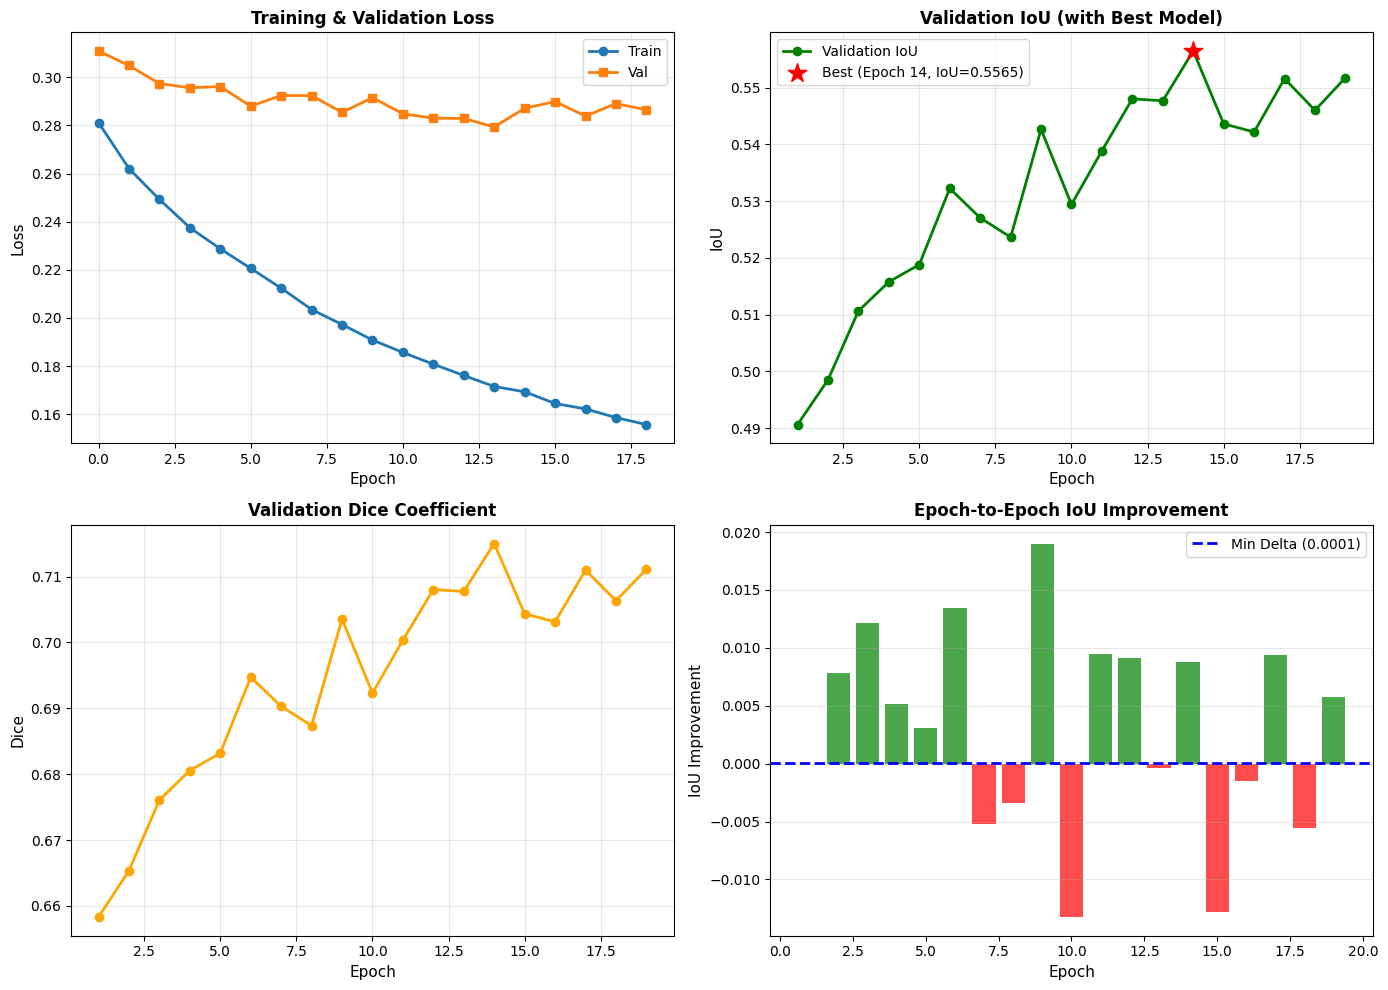

Training history saved to: d:\python\Origin\training_history.png


In [12]:
# Plot training history with early stopping visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss plot
axes[0, 0].plot(history['train_loss'], label='Train', marker='o', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val', marker='s', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Validation IoU plot with best model highlighted
epochs = list(range(1, len(history['val_iou']) + 1))
axes[0, 1].plot(epochs, history['val_iou'], marker='o', color='green', linewidth=2, label='Validation IoU')
if best_epoch <= len(history['val_iou']):
    axes[0, 1].scatter([best_epoch], [best_iou], color='red', s=200, marker='*', 
                       label=f'Best (Epoch {best_epoch}, IoU={best_iou:.4f})', zorder=5)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('IoU', fontsize=11)
axes[0, 1].set_title('Validation IoU (with Best Model)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Validation Dice plot
axes[1, 0].plot(epochs, history['val_dice'], marker='o', color='orange', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Dice', fontsize=11)
axes[1, 0].set_title('Validation Dice Coefficient', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# IoU improvement trend plot
iou_improvements = [0] + [history['val_iou'][i] - history['val_iou'][i-1] for i in range(1, len(history['val_iou']))]
colors = ['green' if x > min_delta else 'red' if x < 0 else 'orange' for x in iou_improvements]
axes[1, 1].bar(epochs, iou_improvements, color=colors, alpha=0.7)
axes[1, 1].axhline(y=min_delta, color='blue', linestyle='--', linewidth=2, label=f'Min Delta ({min_delta})')
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('IoU Improvement', fontsize=11)
axes[1, 1].set_title('Epoch-to-Epoch IoU Improvement', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
training_plot_path = output_dir / 'training_history.png'
plt.savefig(str(training_plot_path), dpi=100, bbox_inches='tight')
plt.show()

print(f"Training history saved to: {training_plot_path}")

## 11. Inference on Validation Samples

Generate predictions on random validation images.

## 10. Inference on Validation Samples

Generate predictions on random validation images.

Generating Predictions from Validation Set
Total validation images: 451
Unique prompts: 10
Sample prompts: ['highlight crack', 'segment crack', 'find cracks']

GROUP 1: Generating predictions on 10 random validation images
  [ 1] crack_Image_-637-_jpg.rf.11158231afd1b7c244e49b7926ac16c1 | Prompt: find drywall joint   | IoU: 0.8504 | Dice: 0.9192
  [ 2] crack_a_31_83_png_jpg.rf.e08b3db9aabdf87f94fa72174e6bfbc5 | Prompt: find drywall joint   | IoU: 0.3053 | Dice: 0.4678
  [ 3] drywall_2000x1500_63_resized_jpg.rf.7e2a817b5a3b73d65cd97235f861ee68 | Prompt: segment wall crack   | IoU: 0.0023 | Dice: 0.0046
  [ 4] crack_crack-bb53c022-dc48-11ed-a81a-88b1113a23b0_jpg.rf.67bb4ea7a638d7e9f3a2f676662086da | Prompt: segment crack        | IoU: 0.5016 | Dice: 0.6681
  [ 5] drywall_2000x1500_35_resized_jpg.rf.eddaf4384439030097e84fe76b0b4de8 | Prompt: segment crack        | IoU: 0.3532 | Dice: 0.5220
  [ 6] crack_294-dat_png_jpg.rf.d78b641552d80dfb5277dab2421fff2c | Prompt: find cracks          | I

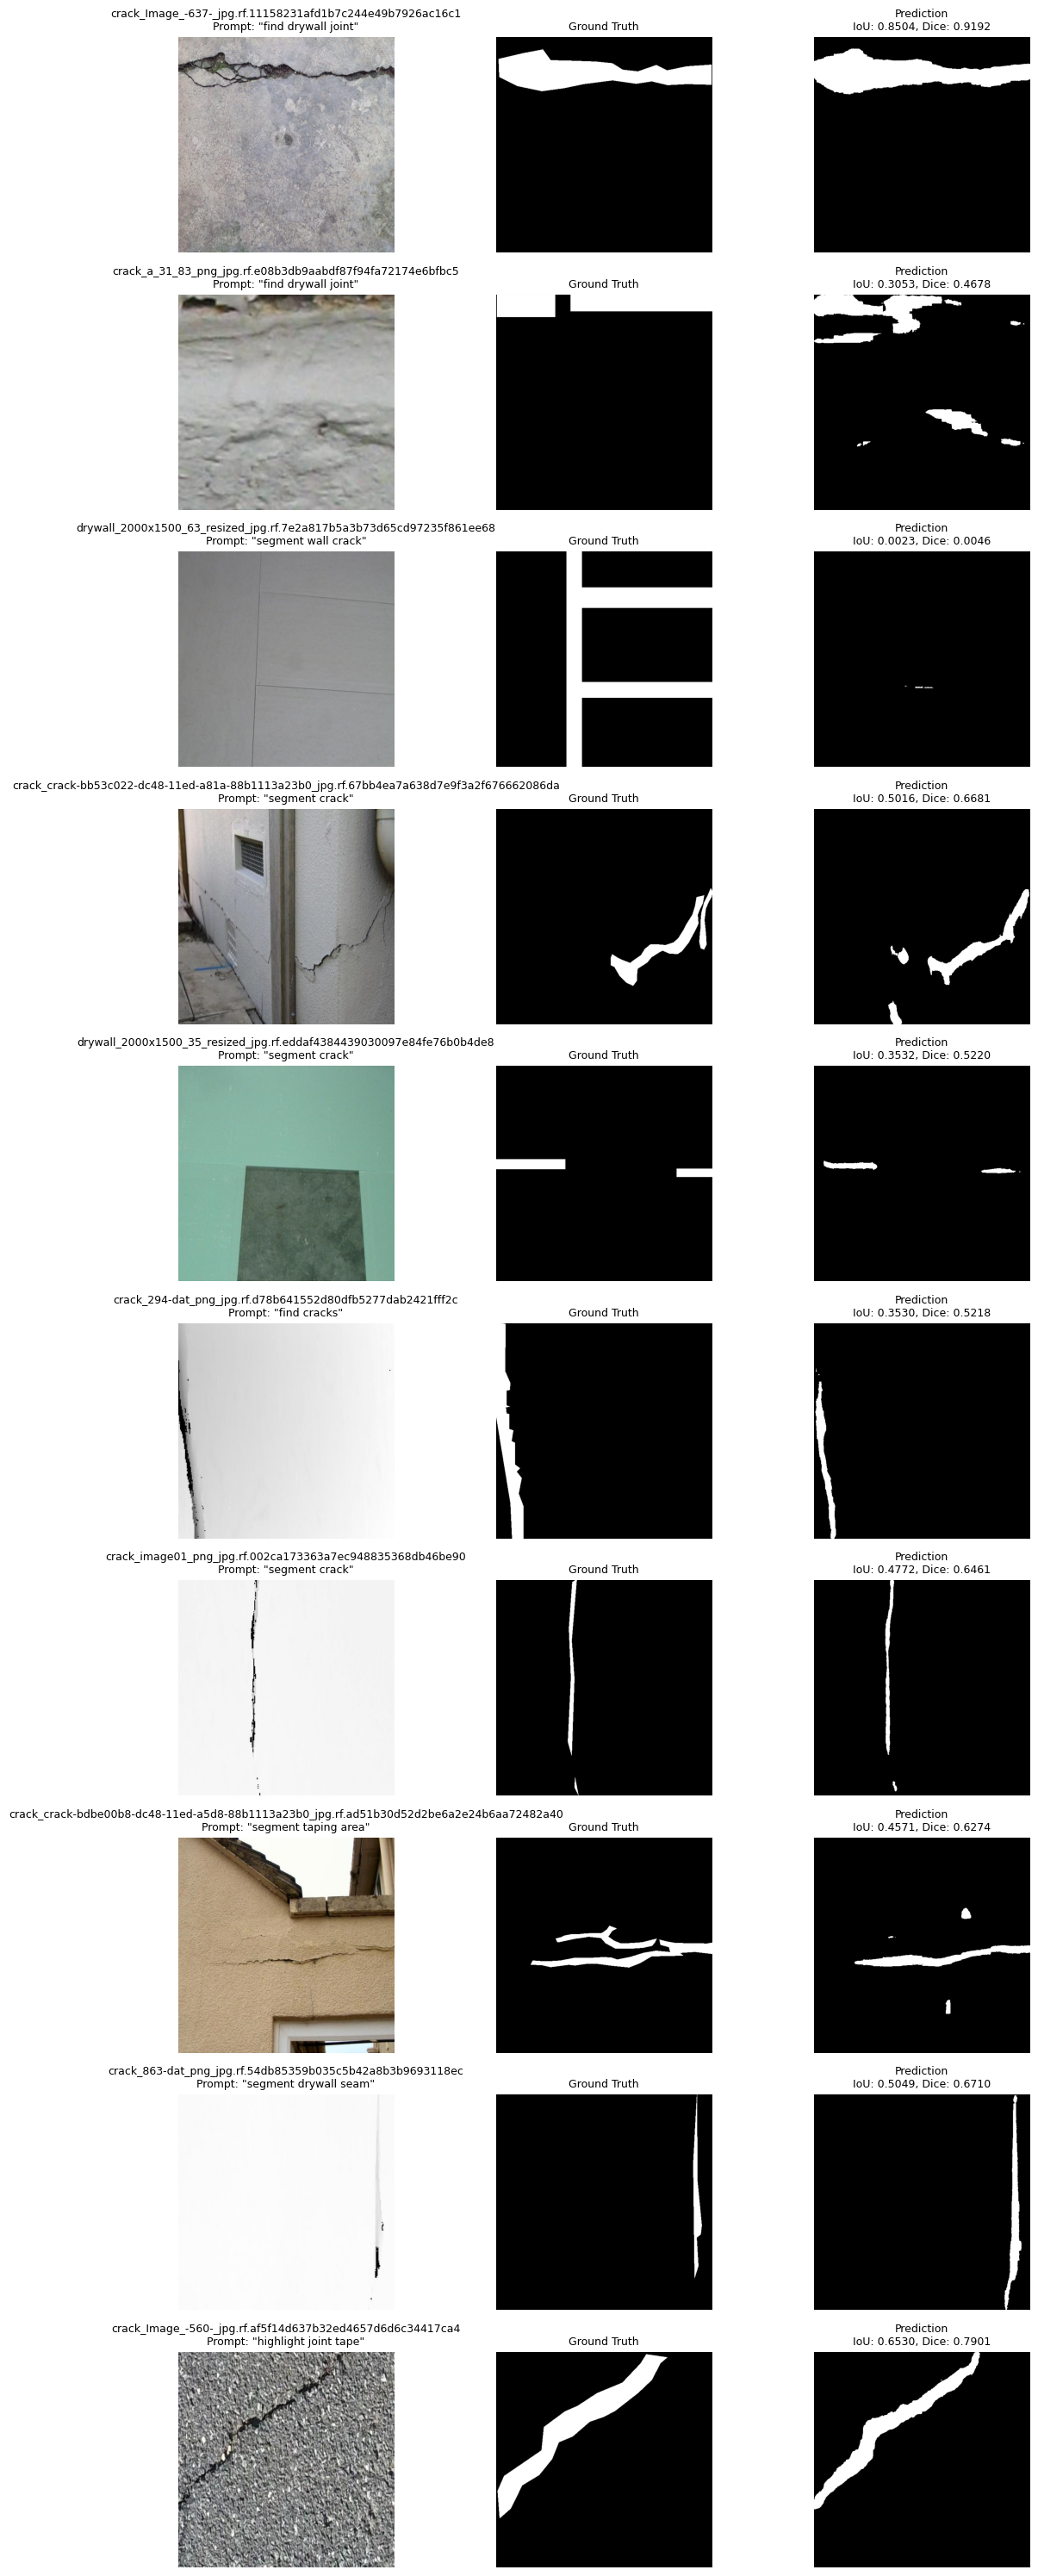


  GROUP 1 AVERAGE: mIoU = 0.4458, mDice = 0.5838
  Saved to: d:\python\Origin\predictions_group1.png

GROUP 2: Generating predictions on 10 random validation images
  [ 1] drywall_IMG_8241_JPG_jpg.rf.6a88a6510f7c4bce568d947798671fc1 | Prompt: highlight crack      | IoU: 0.0802 | Dice: 0.1485
  [ 2] drywall_IMG_8288_JPG_jpg.rf.9807084caf34b0db64eb3c13c9a51de3 | Prompt: find cracks          | IoU: 0.0590 | Dice: 0.1114
  [ 3] drywall_IMG_8241_JPG_jpg.rf.8d402aec06484f5ded5062a90baddf6a | Prompt: highlight joint tape | IoU: 0.2839 | Dice: 0.4422
  [ 4] drywall_IMG_8245_JPG_jpg.rf.4bd3d82155ee4e4882c135220d75b5a6 | Prompt: segment taping area  | IoU: 0.5908 | Dice: 0.7428
  [ 5] drywall_IMG_8308_JPG_jpg.rf.349448d53d9a703e4eba6a42fe477b41 | Prompt: detect drywall seam  | IoU: 0.6017 | Dice: 0.7514
  [ 6] drywall_IMG_8249_JPG_jpg.rf.52f4e43fee79efa622883adc4d10cf49 | Prompt: find drywall joint   | IoU: 0.3620 | Dice: 0.5316
  [ 7] drywall_IMG_8254_JPG_jpg.rf.fe3850dbddda0c581a79d4271d6fbac

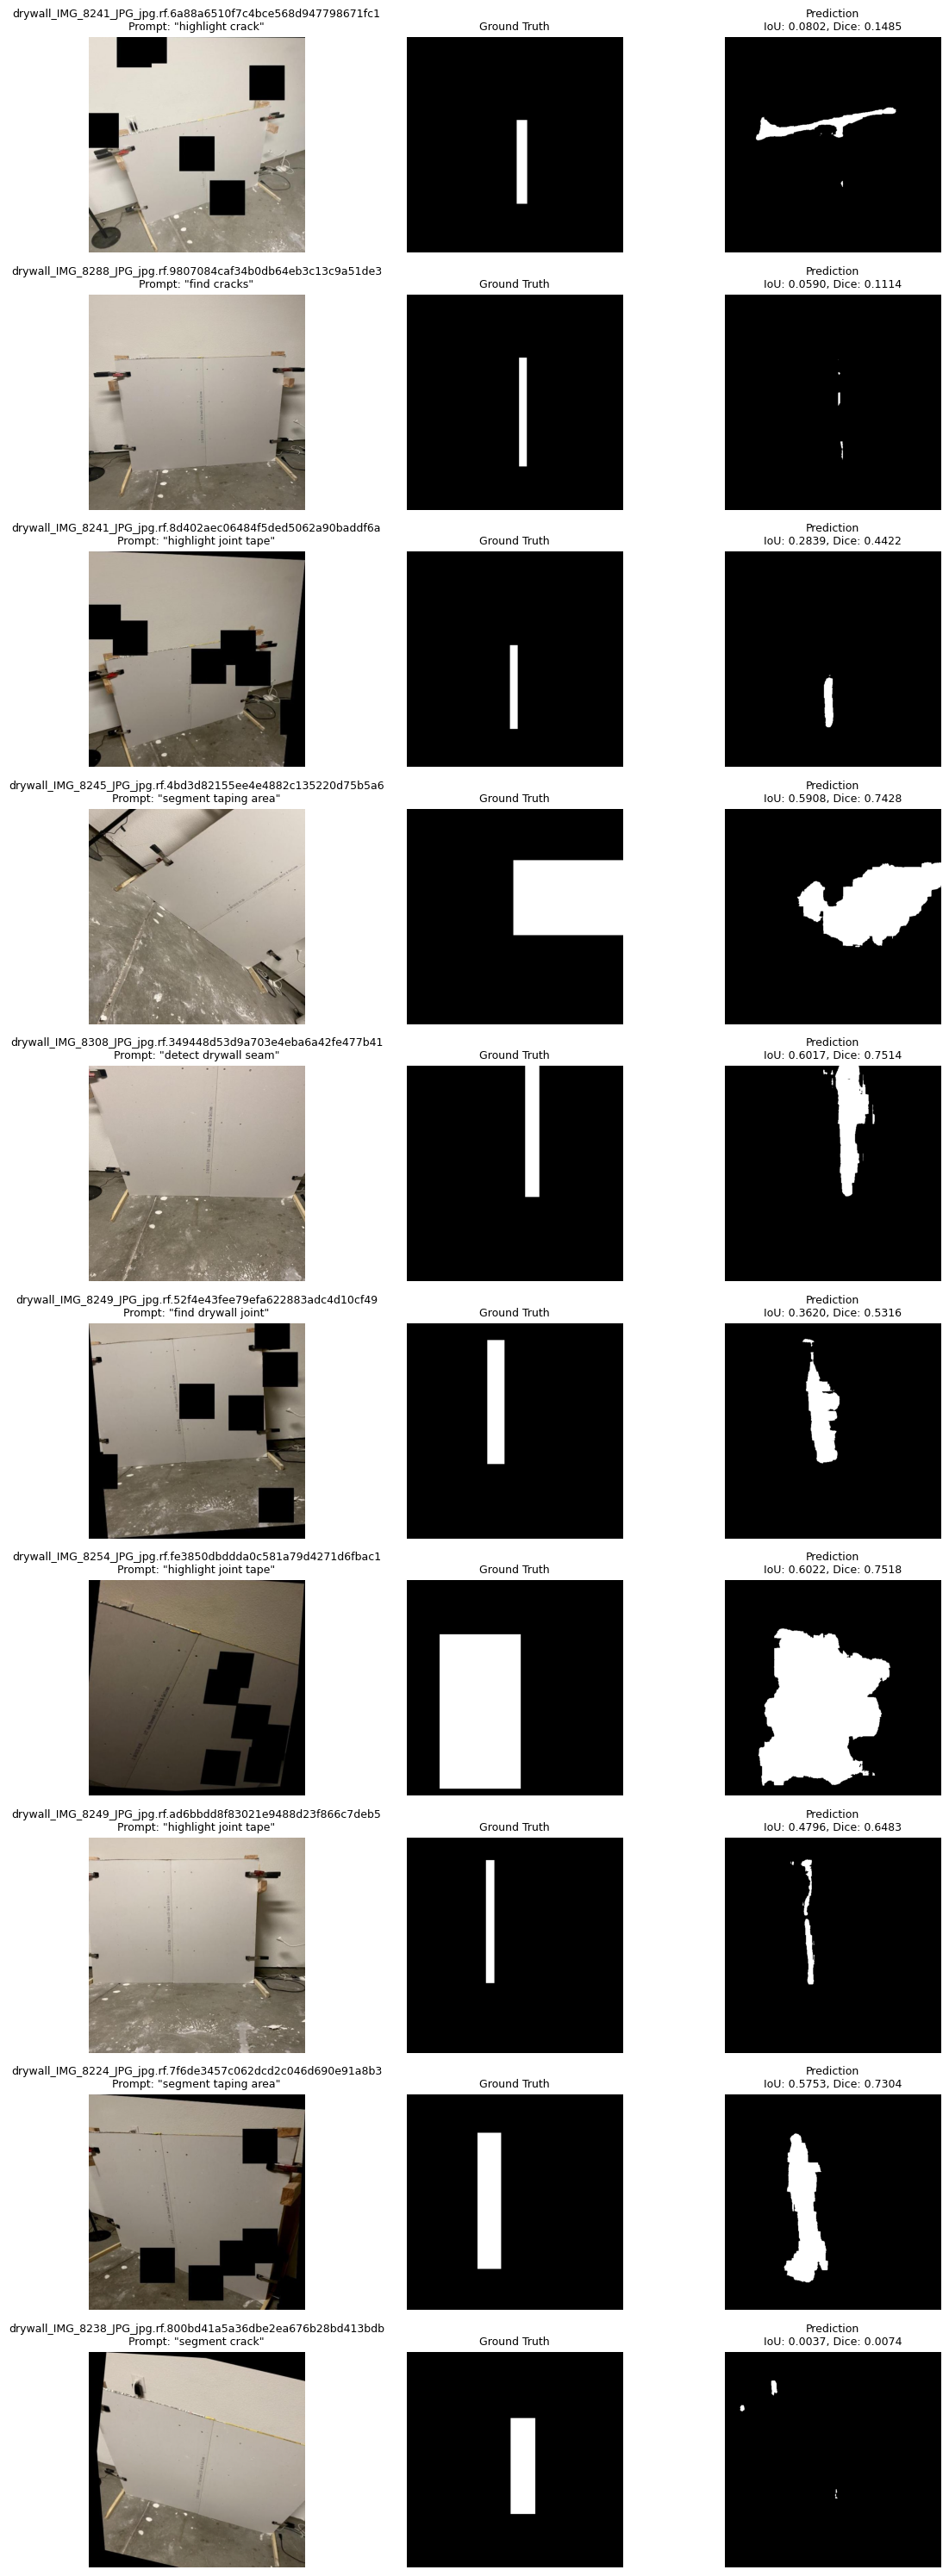


  GROUP 2 AVERAGE: mIoU = 0.3639, mDice = 0.4866
  Saved to: d:\python\Origin\predictions_group2.png

📊 OVERALL PREDICTION SUMMARY
  Group 1   (10 samples): mIoU = 0.4458, mDice = 0.5838
  Group 2   (10 samples): mIoU = 0.3639, mDice = 0.4866
  Combined  (20 samples): mIoU = 0.4048, mDice = 0.5352


In [17]:
# ===== GENERATE PREDICTIONS: FROM VALIDATION DATA ======
print("="*70)
print("Generating Predictions from Validation Set")
print("="*70)

# Load best model
best_model_path = checkpoint_dir / 'best_model.pth'
model.load_state_dict(torch.load(best_model_path))
model.eval()

# Use processed validation data
val_images_dir = data_dir / 'valid' / 'images'
val_masks_dir = data_dir / 'valid' / 'masks'
val_metadata = pd.read_csv(data_dir / 'valid' / 'metadata.csv')

all_images = sorted(list(val_images_dir.glob('*.jpg')))
print(f"Total validation images: {len(all_images)}")

# Get unique prompts
all_prompts = val_metadata['prompt'].unique().tolist()
print(f"Unique prompts: {len(all_prompts)}")
print(f"Sample prompts: {all_prompts[:3]}")

# Helper function to compute metrics
def compute_metrics(pred_mask, gt_mask):
    """Compute IoU and Dice without pycocotools"""
    pred_flat = (pred_mask > 128).astype(np.uint8).flatten()
    gt_flat = (gt_mask > 128).astype(np.uint8).flatten()
    
    # IoU (Jaccard)
    intersection = np.logical_and(pred_flat, gt_flat).sum()
    union = np.logical_or(pred_flat, gt_flat).sum()
    iou = intersection / (union + 1e-6)
    
    # Dice
    dice = 2 * intersection / (pred_flat.sum() + gt_flat.sum() + 1e-6)
    
    return iou, dice

# Split validation set into two groups: first half and second half
split_point = len(all_images) // 2
group_1_images = all_images[:split_point]
group_2_images = all_images[split_point:]

# Generate predictions for GROUP 1 (first half)
print("\n" + "="*70)
print("GROUP 1: Generating predictions on 10 random validation images")
print("="*70)

group1_results = []
group1_indices = np.random.choice(len(group_1_images), size=min(10, len(group_1_images)), replace=False)

fig_group1, axes_g1 = plt.subplots(10, 3, figsize=(12, 30))
if len(group1_indices) == 1:
    axes_g1 = axes_g1.reshape(1, -1)

for plot_idx, img_idx in enumerate(group1_indices):
    img_path = group_1_images[img_idx]
    img_name = img_path.stem
    
    # Find corresponding mask (NOTE: masks are .png, not .jpg)
    mask_path = val_masks_dir / (img_name + '.png')
    
    # Select random prompt
    prompt = np.random.choice(all_prompts)
    
    # Load GT mask
    gt_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if gt_mask is None:
        print(f"  ⚠ Skipping {img_name} - mask not found at {mask_path}")
        continue
    
    # Load image
    img = Image.open(img_path).convert('RGB')
    img_np = np.array(img)
    
    # Generate prediction
    pred_mask, _ = infer(model, img_path, prompt, processor)
    
    # Compute metrics
    iou, dice = compute_metrics(pred_mask, gt_mask)
    
    group1_results.append({
        'image': img_name,
        'prompt': prompt,
        'iou': iou,
        'dice': dice
    })
    
    # Plot
    axes_g1[plot_idx, 0].imshow(img_np)
    axes_g1[plot_idx, 0].set_title(f'{img_name}\nPrompt: "{prompt}"', fontsize=9)
    axes_g1[plot_idx, 0].axis('off')
    
    axes_g1[plot_idx, 1].imshow(gt_mask, cmap='gray')
    axes_g1[plot_idx, 1].set_title('Ground Truth', fontsize=9)
    axes_g1[plot_idx, 1].axis('off')
    
    axes_g1[plot_idx, 2].imshow(pred_mask, cmap='gray')
    axes_g1[plot_idx, 2].set_title(f'Prediction\nIoU: {iou:.4f}, Dice: {dice:.4f}', fontsize=9)
    axes_g1[plot_idx, 2].axis('off')
    
    print(f"  [{plot_idx+1:2d}] {img_name:20s} | Prompt: {prompt:20s} | IoU: {iou:.4f} | Dice: {dice:.4f}")

plt.tight_layout()
group1_pred_path = output_dir / 'predictions_group1.png'
plt.savefig(str(group1_pred_path), dpi=100, bbox_inches='tight')
plt.show()

# Compute average metrics
avg_iou_g1 = np.mean([r['iou'] for r in group1_results]) if group1_results else 0
avg_dice_g1 = np.mean([r['dice'] for r in group1_results]) if group1_results else 0
print(f"\n  GROUP 1 AVERAGE: mIoU = {avg_iou_g1:.4f}, mDice = {avg_dice_g1:.4f}")
print(f"  Saved to: {group1_pred_path}")

# Generate predictions for GROUP 2 (second half)
print("\n" + "="*70)
print("GROUP 2: Generating predictions on 10 random validation images")
print("="*70)

group2_results = []
group2_indices = np.random.choice(len(group_2_images), size=min(10, len(group_2_images)), replace=False)

fig_group2, axes_g2 = plt.subplots(10, 3, figsize=(12, 30))
if len(group2_indices) == 1:
    axes_g2 = axes_g2.reshape(1, -1)

for plot_idx, img_idx in enumerate(group2_indices):
    img_path = group_2_images[img_idx]
    img_name = img_path.stem
    
    # Find corresponding mask (NOTE: masks are .png, not .jpg)
    mask_path = val_masks_dir / (img_name + '.png')
    
    # Select random prompt
    prompt = np.random.choice(all_prompts)
    
    # Load GT mask
    gt_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if gt_mask is None:
        print(f"  ⚠ Skipping {img_name} - mask not found at {mask_path}")
        continue
    
    # Load image
    img = Image.open(img_path).convert('RGB')
    img_np = np.array(img)
    
    # Generate prediction
    pred_mask, _ = infer(model, img_path, prompt, processor)
    
    # Compute metrics
    iou, dice = compute_metrics(pred_mask, gt_mask)
    
    group2_results.append({
        'image': img_name,
        'prompt': prompt,
        'iou': iou,
        'dice': dice
    })
    
    # Plot
    axes_g2[plot_idx, 0].imshow(img_np)
    axes_g2[plot_idx, 0].set_title(f'{img_name}\nPrompt: "{prompt}"', fontsize=9)
    axes_g2[plot_idx, 0].axis('off')
    
    axes_g2[plot_idx, 1].imshow(gt_mask, cmap='gray')
    axes_g2[plot_idx, 1].set_title('Ground Truth', fontsize=9)
    axes_g2[plot_idx, 1].axis('off')
    
    axes_g2[plot_idx, 2].imshow(pred_mask, cmap='gray')
    axes_g2[plot_idx, 2].set_title(f'Prediction\nIoU: {iou:.4f}, Dice: {dice:.4f}', fontsize=9)
    axes_g2[plot_idx, 2].axis('off')
    
    print(f"  [{plot_idx+1:2d}] {img_name:20s} | Prompt: {prompt:20s} | IoU: {iou:.4f} | Dice: {dice:.4f}")

plt.tight_layout()
group2_pred_path = output_dir / 'predictions_group2.png'
plt.savefig(str(group2_pred_path), dpi=100, bbox_inches='tight')
plt.show()

# Compute average metrics
avg_iou_g2 = np.mean([r['iou'] for r in group2_results]) if group2_results else 0
avg_dice_g2 = np.mean([r['dice'] for r in group2_results]) if group2_results else 0
print(f"\n  GROUP 2 AVERAGE: mIoU = {avg_iou_g2:.4f}, mDice = {avg_dice_g2:.4f}")
print(f"  Saved to: {group2_pred_path}")

# Overall summary
print("\n" + "="*70)
print("📊 OVERALL PREDICTION SUMMARY")
print("="*70)
print(f"  Group 1   ({len(group1_results)} samples): mIoU = {avg_iou_g1:.4f}, mDice = {avg_dice_g1:.4f}")
print(f"  Group 2   ({len(group2_results)} samples): mIoU = {avg_iou_g2:.4f}, mDice = {avg_dice_g2:.4f}")
if len(group1_results) > 0 or len(group2_results) > 0:
    total_samples = len(group1_results) + len(group2_results)
    combined_miou = (avg_iou_g1 * len(group1_results) + avg_iou_g2 * len(group2_results)) / total_samples if total_samples > 0 else 0
    combined_dice = (avg_dice_g1 * len(group1_results) + avg_dice_g2 * len(group2_results)) / total_samples if total_samples > 0 else 0
    print(f"  Combined  ({total_samples} samples): mIoU = {combined_miou:.4f}, mDice = {combined_dice:.4f}")
print("="*70)

In [14]:
# ===== DEBUG: Check data availability ======
print("="*70)
print("Debugging: Checking Validation Data")
print("="*70)

val_images_dir = data_dir / 'valid' / 'images'
val_masks_dir = data_dir / 'valid' / 'masks'

all_images = sorted(list(val_images_dir.glob('*.jpg')))
all_masks = sorted(list(val_masks_dir.glob('*.jpg')))

print(f"Total images: {len(all_images)}")
print(f"Total masks: {len(all_masks)}")

# Check if image names match mask names
img_names = set([p.stem for p in all_images])
mask_names = set([p.stem for p in all_masks])

matching = img_names.intersection(mask_names)
print(f"Matching image-mask pairs: {len(matching)}")

# Sample check
if all_images:
    sample_img = all_images[0]
    sample_mask_path = val_masks_dir / (sample_img.stem + '.jpg')
    print(f"\nSample image: {sample_img.name}")
    print(f"Expected mask: {sample_mask_path.name}")
    print(f"Mask exists: {sample_mask_path.exists()}")
    
    if sample_mask_path.exists():
        mask = cv2.imread(str(sample_mask_path), cv2.IMREAD_GRAYSCALE)
        print(f"Mask shape: {mask.shape if mask is not None else 'None'}")
        print(f"Mask min/max: [{mask.min()}, {mask.max()}]" if mask is not None else 'N/A')


Debugging: Checking Validation Data
Total images: 451
Total masks: 0
Matching image-mask pairs: 0

Sample image: crack_1045-dat_png_jpg.rf.c6bc68ac619ab1ec0ef4b870b8c7c54c.jpg
Expected mask: crack_1045-dat_png_jpg.rf.c6bc68ac619ab1ec0ef4b870b8c7c54c.jpg
Mask exists: False
